In [1]:
#imports
import os
import tkinter
from tkinter import filedialog

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pyomeca

from pyomeca import Rototrans, Angles
from ezc3d import c3d
import numpy as np
import numpy as np
import pandas as pd
from pandas import DataFrame
np.set_printoptions(threshold=np.inf)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

import csv

In [6]:
# Reset tkinter
root = tkinter.Tk()
root.withdraw()
root.call('wm', 'attributes', '.', '-topmost', True)

#using ezc3d
c3d_file = filedialog.askopenfilename(title='Select theia c3d')
c3d_file = os.path.normpath(c3d_file)
c = c3d(c3d_file)

In [ ]:
# Find the sampling rate and total frame count from the C3D metadata.
frame_rate = (c['parameters']['POINT']['RATE']['value'])
total_frames = (c['parameters']['POINT']['FRAMES']['value'])
total_frames = int(total_frames)
frame_values = list(range(total_frames))

In [ ]:
# Convert frame numbers to elapsed time in seconds.
def calculate_time_per_frame(frame_rate, total_frames):
    time_per_frame = 1 / frame_rate
    return [time_per_frame] * total_frames

individual_times = calculate_time_per_frame(frame_rate, total_frames)
time = np.round((frame_values / frame_rate),5)

In [10]:
# Get list of segment pose matricies
keysList = c['parameters']['ROTATION']['LABELS']['value']

print(keysList)

['worldbody_4X4', 'pelvis_4X4', 'l_thigh_4X4', 'l_shank_4X4', 'l_foot_4X4', 'l_toes_4X4', 'r_thigh_4X4', 'r_shank_4X4', 'r_foot_4X4', 'r_toes_4X4', 'head_4X4', 'torso_4X4', 'l_uarm_4X4', 'l_larm_4X4', 'l_hand_4X4', 'r_uarm_4X4', 'r_larm_4X4', 'r_hand_4X4', 'pelvis_shifted_4X4']


In [ ]:
# Get rotation data from ezc3d.
rotation_data = c['data']['rotations']

# Move the segment index to the front so each 4x4 pose matrix is easy to slice.
rotation_data_transposed  = np.transpose(rotation_data, (2, 0, 1, 3))

# Extract the pelvis pose matrix and replace missing values with zeros.
pelvis_4X4 = rotation_data_transposed[keysList.index('pelvis_4X4')]
pelvis_4X4 = np.nan_to_num(pelvis_4X4, nan=0)
pelvis_4X4[3, :, :] = np.array([0, 0, 0, 1])[:, np.newaxis]

# Convert the pose matrix into a Rototrans object and then extract Euler angles.
pelvis_rt = Rototrans(pelvis_4X4)
pelvis_rt_t = Rototrans.from_transposed_rototrans(pelvis_rt)
pelvis_rt_t = Rototrans(pelvis_rt)

# These are the pelvis angles used in the OpenSim motion file.
pelvis_angles = Angles.from_rototrans(pelvis_rt_t,'xyz')

NameError: name 'keysList' is not defined

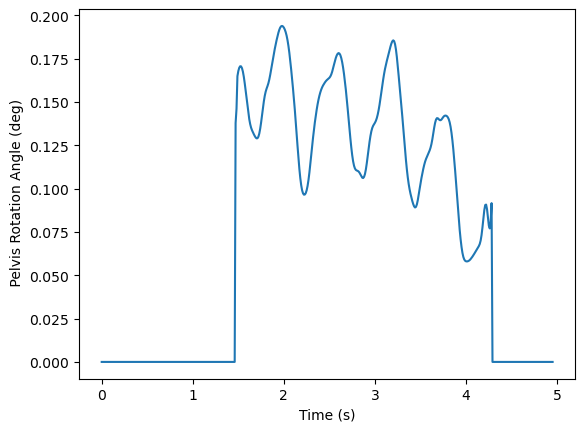

In [13]:
pelvisrot = pelvis_angles[0, 0, :]
plt.plot(time, pelvisrot)
plt.ylabel(" Pelvis Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.show()

pelvisrot = np.round(pelvisrot,2)

Text(0.5, 0, 'Time (s)')

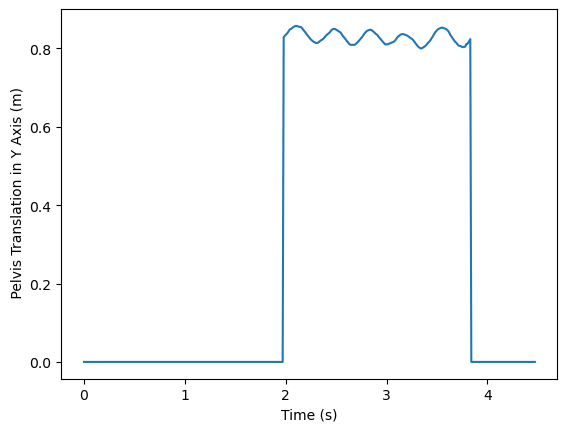

In [8]:
pelvis_ty = pelvis_4X4[2, 3]/1000  # Index 1 for y-axis, row 3 for translation, z for theia is y for global
plt.plot(time, pelvis_ty)
pelvis_ty = np.round(pelvis_ty,2)
plt.ylabel(" Pelvis Translation in Y Axis (m)")
plt.xlabel("Time (s)")
#plt.xlim(0,1.49)
#print(pelvis_ty)

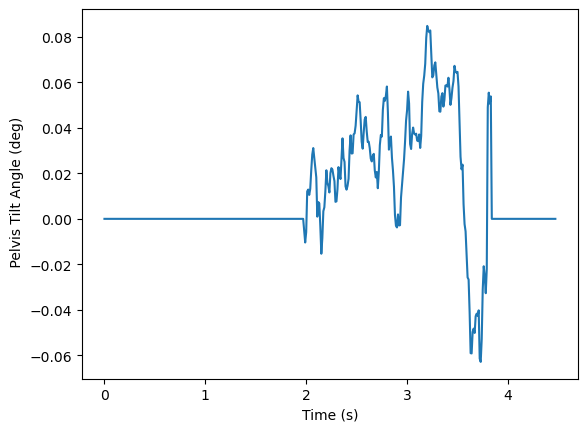

In [9]:
#pelvistilt = pelvis_angles.sel(axis=1).values.flatten()
pelvistilt = pelvis_angles[1, 0, :]
plt.plot(time, pelvistilt)
#plt.xlim(0,1.49)
plt.ylabel(" Pelvis Tilt Angle (deg)")
plt.xlabel("Time (s)")
plt.show()

pelvistilt = np.round(pelvistilt,2)

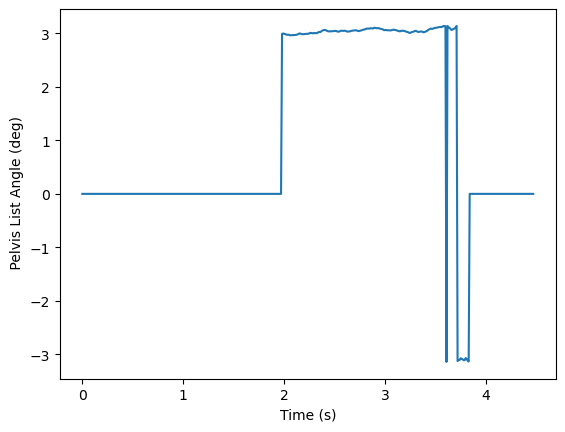

In [10]:
pelvislist = pelvis_angles[2, 0, :]
plt.plot(time, pelvislist)
plt.ylabel(" Pelvis List Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,2.1)
plt.show()

pelvislist = np.round(pelvislist,2)

In [17]:
# Get rotation data
rotation_data = c['data']['rotations']
# Reorder rotation data to make pose label first last (not required)
rotation_data_transposed  = np.transpose(rotation_data, (2, 0, 1, 3))

torso_4X4 = rotation_data_transposed[keysList.index('torso_4X4')]

torso_4X4 = np.nan_to_num(torso_4X4, nan=0)
torso_4X4[3, :, :] = np.array([0, 0, 0, 1])[:, np.newaxis]

torso_rt = Rototrans(torso_4X4)
pelvis_rt = Rototrans(pelvis_4X4)

torso_rt_t = Rototrans.from_transposed_rototrans(torso_rt)

lumbar_rt = np.einsum('ijt, jkt -> ikt', torso_rt_t, pelvis_rt)

lumbar_rt = Rototrans(lumbar_rt)

lumbar_angles = Angles.from_rototrans(lumbar_rt,'xyz')

lumbar_angles = np.degrees(lumbar_angles)

#print(lumbar_angles)

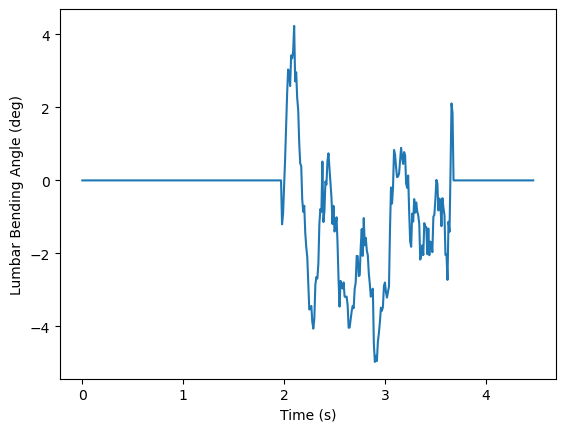

In [12]:
#axb1 = plt.gca()
lumbarbending = lumbar_angles.sel(axis=0).values.flatten()
plt.ylabel("Lumbar Bending Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,1.49)
plt.plot(time, lumbarbending)
plt.show()

lumbarbending = np.round(lumbarbending,2)
#print(lumbarbending)

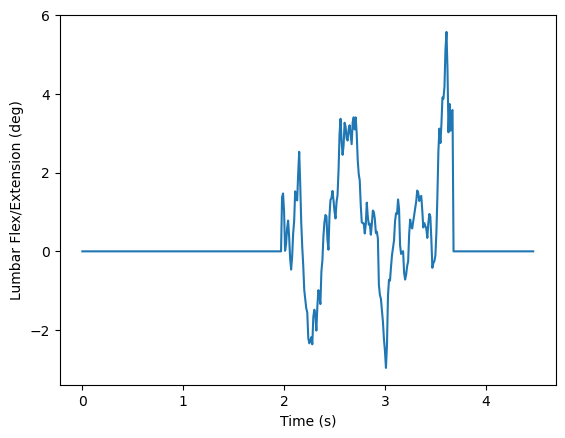

In [13]:
#axb2 = plt.gca()
lumbarflex = lumbar_angles.sel(axis=1).values.flatten()
plt.ylabel("Lumbar Flex/Extension (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,1.49)
plt.plot(time, lumbarflex)
plt.show()

lumbarflex = np.round(lumbarflex,2)

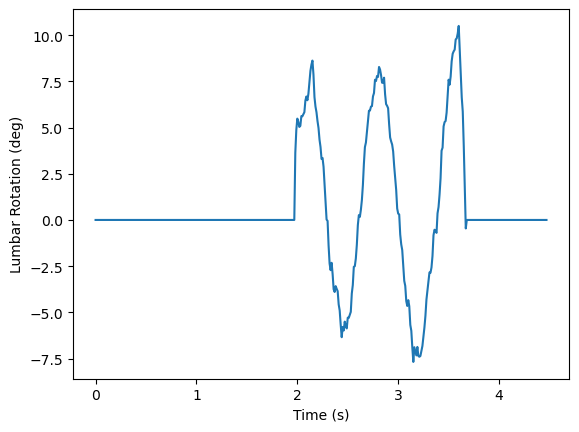

In [14]:
lumbarrot = lumbar_angles.sel(axis=2).values.flatten()
plt.ylabel("Lumbar Rotation (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,2.1)
plt.plot(time, lumbarrot)
plt.show()

lumbarrot = np.round(lumbarrot,2)

In [19]:
# Reorder rotation data to make pose label first last (not required)
rotation_data_transposed  = np.transpose(rotation_data, (2, 0, 1, 3))

l_thigh_4X4 = rotation_data_transposed[keysList.index('l_thigh_4X4')]
l_shank_4X4 = rotation_data_transposed[keysList.index('l_shank_4X4')]

l_thigh_4X4 = np.nan_to_num(l_thigh_4X4, nan=0)
l_thigh_4X4[3, :, :] = np.array([0, 0, 0, 1])[:, np.newaxis]

# Fix pelvis matrix
l_shank_4X4 = np.nan_to_num(l_shank_4X4, nan=0)
l_shank_4X4[3, :, :] = np.array([0, 0, 0, 1])[:, np.newaxis]

l_thigh_rt = Rototrans(l_thigh_4X4)
l_shank_rt = Rototrans(l_shank_4X4)
l_thigh_rt_t = Rototrans.from_transposed_rototrans(l_thigh_rt)

l_knee_rt = np.einsum('ijt, jkt -> ikt', l_thigh_rt_t, l_shank_rt)
l_knee_rt = Rototrans(l_knee_rt)

knee_angles_l = Angles.from_rototrans(l_knee_rt,'xyz')
knee_angles_l = np.degrees(knee_angles_l)

#print(knee_angles_l)

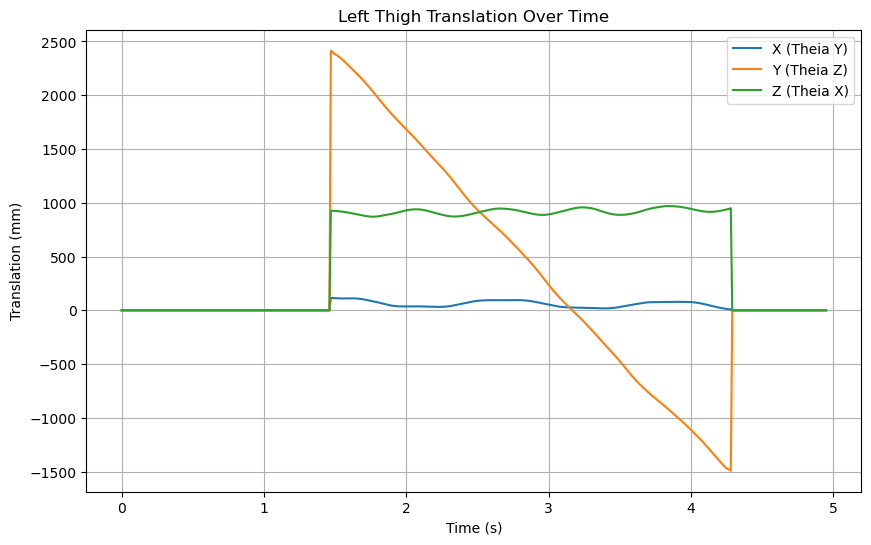

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Extract translations from l_thigh_4X4 (shape: [4, 4, N])
l_thigh_translations = l_thigh_4X4[:3, 3, :].T  # Shape: [N, 3] (x, y, z)

# Create a time array (assuming frame_rate and total_frames are defined)
time = np.arange(l_thigh_translations.shape[0]) / frame_rate

# Plot translations
plt.figure(figsize=(10, 6))
plt.plot(time, l_thigh_translations[:, 0], label='X (Theia Y)')
plt.plot(time, l_thigh_translations[:, 1], label='Y (Theia Z)')
plt.plot(time, l_thigh_translations[:, 2], label='Z (Theia X)')
plt.xlabel('Time (s)')
plt.ylabel('Translation (mm)')
plt.title('Left Thigh Translation Over Time')
plt.legend()
plt.grid(True)
plt.show()


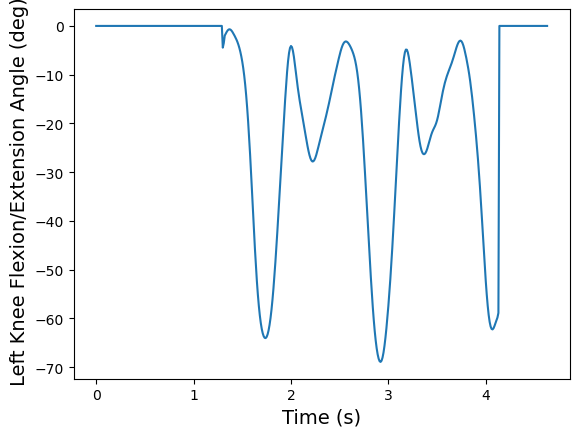

In [17]:
lkneeflex = knee_angles_l.sel(axis=0).values.flatten()
plt.ylabel(" Left Knee Flexion/Extension Angle (deg)", fontsize=14)
plt.xlabel("Time (s)", fontsize=14)
#plt.xlim(0,1.8)
plt.plot(time,lkneeflex)
plt.show()

lkneeflex = np.round(lkneeflex,2)

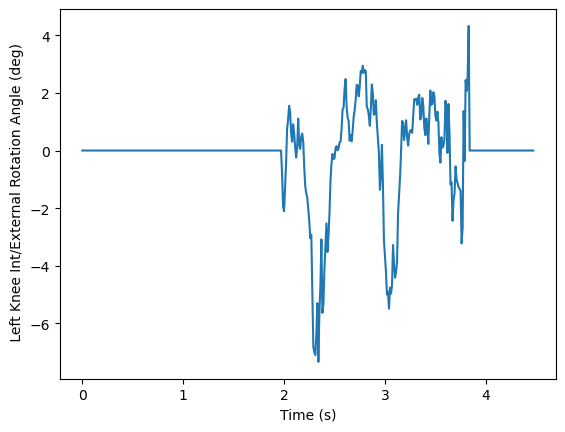

In [17]:
lkneerot = knee_angles_l.sel(axis=1).values.flatten()
plt.ylabel(" Left Knee Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,2.1)
plt.plot(time, lkneerot)
plt.show()

lkneerot = np.round(lkneerot,2)

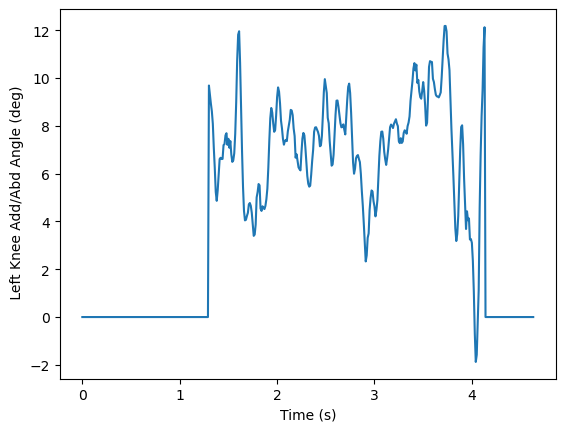

In [21]:
lkneeadd = knee_angles_l.sel(axis=2).values.flatten()
plt.ylabel(" Left Knee Add/Abd Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,2.1)
plt.plot(time, lkneeadd)
plt.show()

lkneeadd = np.round(lkneeadd,2)

In [23]:
r_thigh_4X4 = rotation_data_transposed[keysList.index('r_thigh_4X4')]
r_shank_4X4 = rotation_data_transposed[keysList.index('r_shank_4X4')]

r_thigh_4X4 = np.nan_to_num(r_thigh_4X4, nan=0)
r_thigh_4X4[3, :, :] = np.array([0, 0, 0, 1])[:, np.newaxis]

r_shank_4X4 = np.nan_to_num(r_shank_4X4, nan=0)
r_shank_4X4[3, :, :] = np.array([0, 0, 0, 1])[:, np.newaxis]

r_thigh_rt = Rototrans(r_thigh_4X4)
r_shank_rt = Rototrans(r_shank_4X4)

r_thigh_rt_t = Rototrans.from_transposed_rototrans(r_thigh_rt)
r_knee_rt = np.einsum('ijt, jkt -> ikt', r_thigh_rt_t, r_shank_rt)
r_knee_rt = Rototrans(r_knee_rt)

knee_angles_r = Angles.from_rototrans(r_knee_rt,'xyz')
knee_angles_r = np.degrees(knee_angles_r)

#print(knee_angles_r)

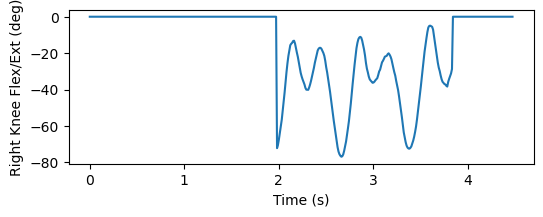

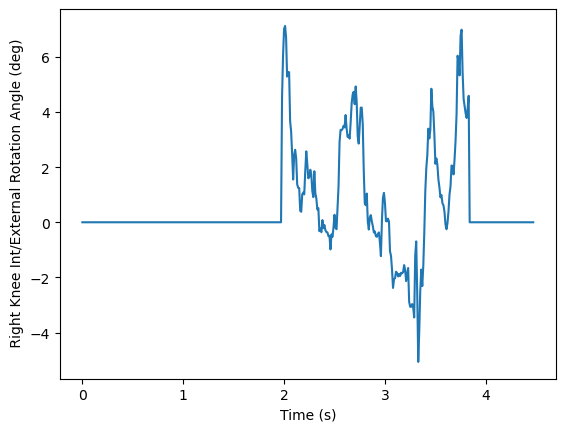

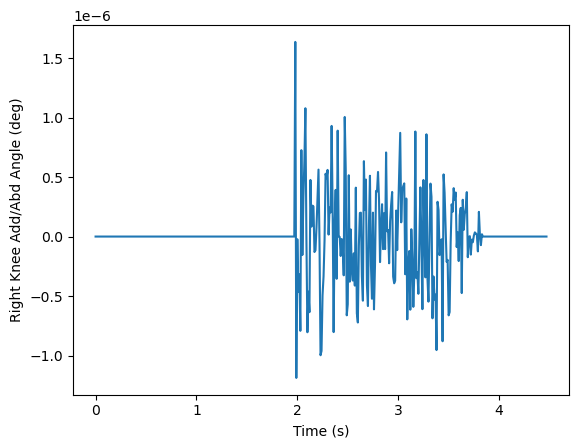

In [97]:
# rkneeflex = knee_angles_r.sel(axis=0).values.flatten()
# plt.ylabel(" Right Knee Flexion/Extension Angle (deg)")
# plt.xlabel("Time (s)")
# #plt.xlim(0,1.8)
# plt.plot(time,rkneeflex)
# plt.show()
# rkneeflex = np.round(rkneeflex,2)

rkneeflex = knee_angles_r.sel(axis=0).values.flatten()
plt.figure(figsize=(6, 2))  # Only applies to this plot
plt.ylabel("Right Knee Flex/Ext (deg)")
plt.xlabel("Time (s)")
plt.plot(time, rkneeflex)
plt.show()
rkneeflex = np.round(rkneeflex, 2)

rkneerot = knee_angles_r.sel(axis=1).values.flatten()
plt.ylabel(" Right Knee Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,1.8)
plt.plot(time,rkneerot)
plt.show()
rkneerot = np.round(rkneerot,2)

rkneeadd = knee_angles_r.sel(axis=2).values.flatten()
plt.ylabel("Right Knee Add/Abd Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,1.8)
plt.plot(time,rkneeadd)
plt.show()
rkneeadd = np.round(rkneeadd,2)

In [21]:
l_thigh_rt = Rototrans(l_thigh_4X4)
pelvis_rt_t = Rototrans.from_transposed_rototrans(pelvis_rt)

l_hip_rt = np.einsum('ijt, jkt -> ikt', pelvis_rt_t, l_thigh_rt)
l_hip_rt = Rototrans(l_hip_rt)

l_hip_angles = Angles.from_rototrans(l_hip_rt,'xyz')
l_hip_angles = np.degrees(l_hip_angles)

#print(l_hip_angles)

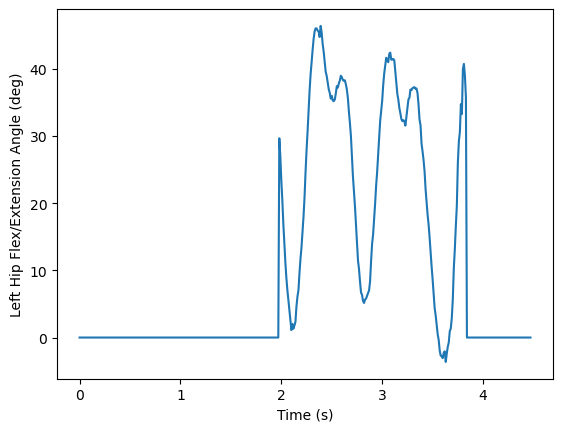

In [22]:
lhipflex = l_hip_angles.sel(axis=0).values.flatten()
plt.ylabel("Left Hip Flex/Extension Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,2.2)
plt.plot(time,lhipflex)
plt.show()
lhipflex = np.round(lhipflex,2)

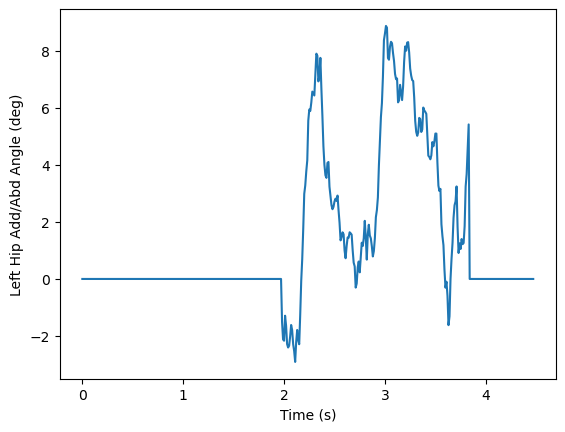

In [23]:
lhipadd = l_hip_angles.sel(axis=1).values.flatten()
plt.ylabel("Left Hip Add/Abd Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(2,4)
plt.plot(time,lhipadd)
plt.show()
lhipadd = np.round(lhipadd,2)

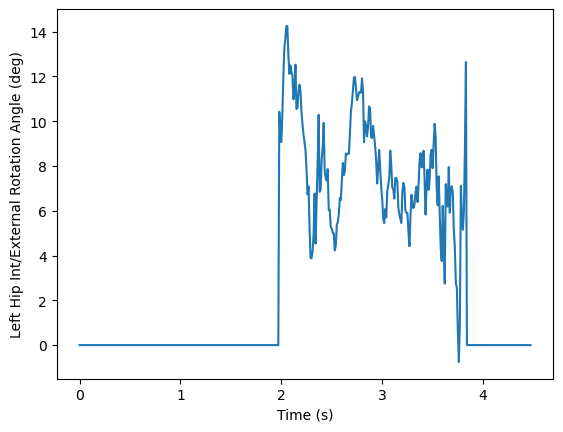

In [24]:
lhiprot = l_hip_angles.sel(axis=2).values.flatten()
plt.ylabel("Left Hip Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(2,4)
plt.plot(time,lhiprot)
plt.show()
lhiprot = np.round(lhiprot,2)

In [25]:
pelvis_rt = Rototrans(pelvis_4X4)
r_thigh_rt = Rototrans(r_thigh_4X4)
pelvis_rt_t = Rototrans.from_transposed_rototrans(pelvis_rt)

r_hip_rt = np.einsum('ijt, jkt -> ikt', pelvis_rt_t, r_thigh_rt)
r_hip_rt = Rototrans(r_hip_rt)

r_hip_angles = Angles.from_rototrans(r_hip_rt,'xyz')
r_hip_angles = np.degrees(r_hip_angles)

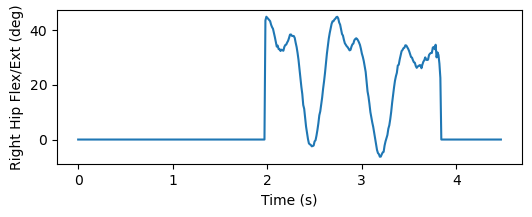

In [101]:
rhipflex = r_hip_angles.sel(axis=0).values.flatten()
plt.figure(figsize=(6, 2))  # Only applies to this plot
plt.ylabel("Right Hip Flex/Ext (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,2.2)
plt.plot(time,rhipflex)
plt.show()
rhipflex = np.round(rhipflex,2)

# print(rhipflex)

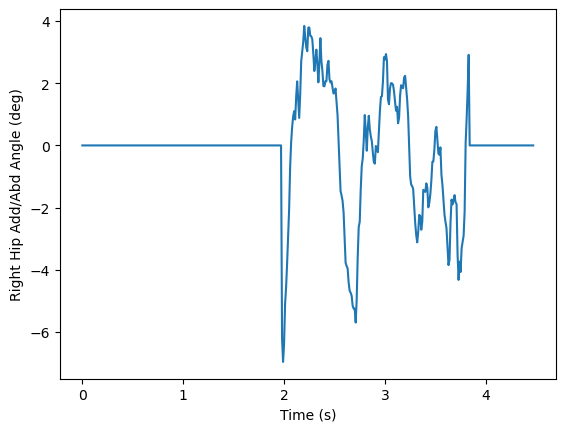

In [27]:
rhipadd = r_hip_angles.sel(axis=1).values.flatten()
plt.ylabel("Right Hip Add/Abd Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,2.2)
plt.plot(time,rhipadd)
plt.show()
rhipadd = np.round(rhipadd,2)

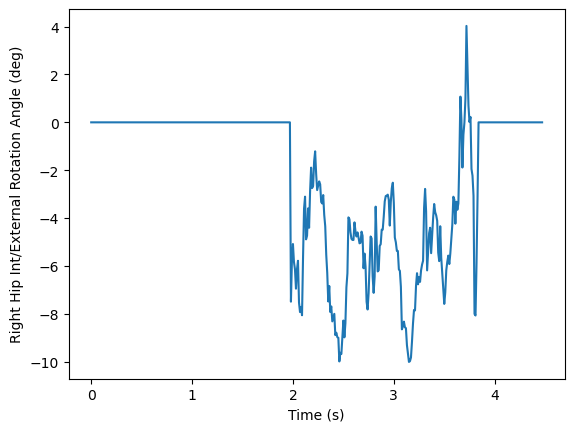

In [28]:
rhiprot = r_hip_angles.sel(axis=2).values.flatten()
plt.ylabel("Right Hip Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,2.2)
plt.plot(time,rhiprot)
plt.show()
rhiprot = np.round(rhiprot,2)

In [25]:
l_foot_4X4 = rotation_data_transposed[keysList.index('l_foot_4X4')]

l_foot_4X4 = np.nan_to_num(l_foot_4X4, nan=0)
l_foot_4X4[3, :, :] = np.array([0, 0, 0, 1])[:, np.newaxis]

l_foot_rt = Rototrans(l_foot_4X4)
l_shank_rt_t = Rototrans.from_transposed_rototrans(l_shank_rt)

l_ankle_rt = np.einsum('ijt, jkt -> ikt', l_shank_rt_t, l_foot_rt)
l_ankle_rt = Rototrans(l_ankle_rt)

ankle_angle_l = Angles.from_rototrans(l_ankle_rt,'xyz')
ankle_angle_l = np.degrees(ankle_angle_l)

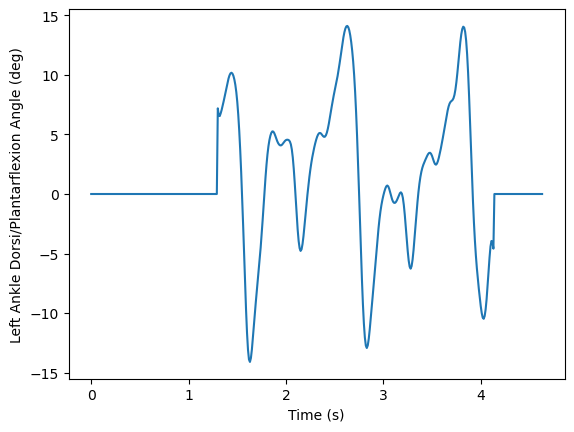

In [27]:
lankleflex = ankle_angle_l.sel(axis=0).values.flatten()
plt.ylabel("Left Ankle Dorsi/Plantarflexion Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,2.2)
plt.plot(time,lankleflex)
plt.show()

lankleflex = np.round(lankleflex,2)

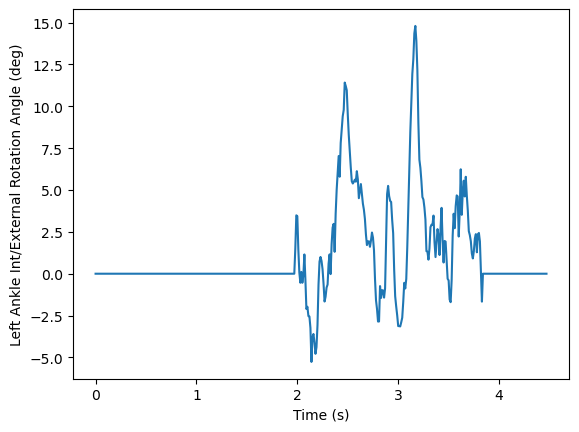

In [31]:
lanklerot = ankle_angle_l.sel(axis=2).values.flatten()
plt.ylabel("Left Ankle Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,2.2)
plt.plot(time,lanklerot)
plt.show()
lanklerot = np.round(lanklerot,2)

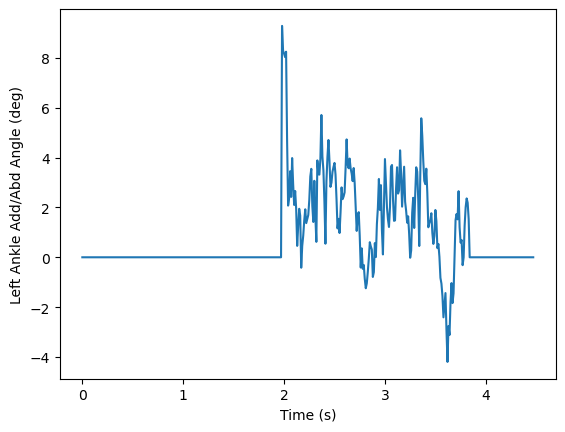

In [32]:
lankleadd = ankle_angle_l.sel(axis=1).values.flatten()
plt.ylabel("Left Ankle Add/Abd Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,1.73)
plt.plot(time,lankleadd)
plt.show()
lankleadd = np.round(lankleadd,2)

In [27]:
r_foot_4X4 = rotation_data_transposed[keysList.index('r_foot_4X4')]

r_foot_4X4 = np.nan_to_num(r_foot_4X4, nan=0)
r_foot_4X4[3, :, :] = np.array([0, 0, 0, 1])[:, np.newaxis]

r_foot_rt = Rototrans(r_foot_4X4)
r_shank_rt_t = Rototrans.from_transposed_rototrans(r_shank_rt)

r_ankle_rt = np.einsum('ijt, jkt -> ikt', r_shank_rt_t, r_foot_rt)
r_ankle_rt = Rototrans(r_ankle_rt)
ankle_angle_r = Angles.from_rototrans(r_ankle_rt,'xyz')
ankle_angle_r = np.degrees(ankle_angle_r)
#print(ankle_angle_r)

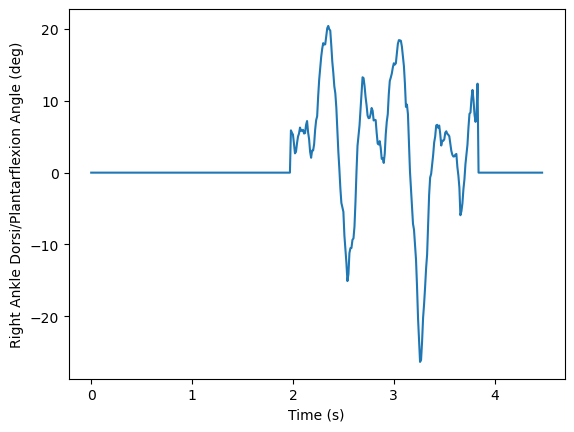

In [34]:
rankleflex = ankle_angle_r.sel(axis=0).values.flatten()
plt.ylabel("Right Ankle Dorsi/Plantarflexion Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,1.73)
plt.plot(time,rankleflex)
plt.show()
rankleflex = np.round(rankleflex,2)

In [ ]:
ranklerot = ankle_angle_r.sel(axis=2).values.flatten()
plt.ylabel("Right Ankle Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,1.73)
plt.plot(time,ranklerot)
plt.show()
ranklerot = np.round(ranklerot,2)

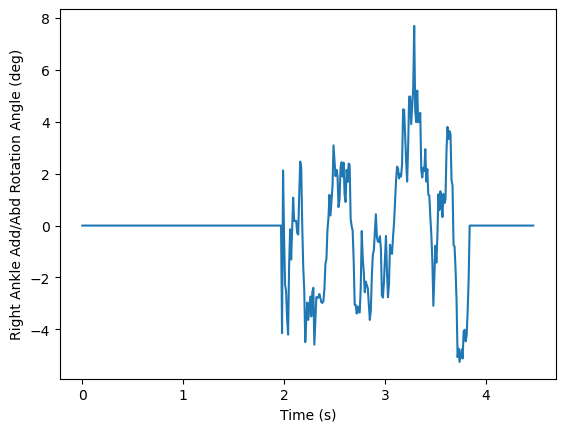

In [36]:
rankleadd = ankle_angle_r.sel(axis=1).values.flatten()
plt.ylabel("Right Ankle Add/Abd Rotation Angle (deg)")
plt.xlabel("Time (s)")
#plt.xlim(0,1.73)
plt.plot(time,rankleadd)
plt.show()
rankleadd = np.round(rankleadd,2)

In [29]:
r_toes_4X4 = rotation_data_transposed[keysList.index('r_toes_4X4')]
l_toes_4X4 = rotation_data_transposed[keysList.index('l_toes_4X4')]

In [ ]:
# Build the OpenSim-ready motion table from the calculated joint angles.
import pandas as pd

np.set_printoptions(suppress=True)

data = {
    'time': time, 
    'pelvis_list': pelvislist,
    'pelvis_rotation': pelvisrot,
    'pelvis_tilt': pelvistilt,	
    'hip_flexion_r': rhipflex,	
    'hip_adduction_r': rhipadd,	
    'hip_rotation_r': rhiprot,
    'knee_angle_r': rkneeflex,
    'ankle_angle_r': rankleflex,
    'hip_flexion_l': lhipflex,	
    'hip_adduction_l': lhipadd,
    'hip_rotation_l': lhiprot,
    'knee_angle_l': lkneeflex,
    'ankle_angle_l': lankleflex,
    'pelvis_ty': pelvis_ty,
    'lumbarbending': lumbarbending,
    'lumbar_rotation': lumbarrot,
    'lumbar_extension': lumbarflex
}

# Convert to a pandas DataFrame and make sure everything is numeric before export.
df = pd.DataFrame(data)
df = df.apply(pd.to_numeric, errors='coerce')

# OpenSim MOT headers must describe table size and time range.
header_lines = [
    "OS.mot",
    "version=1",
    "datacolumns " + str(df.shape[1]),
    "datarows " + str(df.shape[0]),
    "range 0 " + str(total_frames) ,
    "inDegrees=yes",
    "endheader"
 ]

# Write the header, then column names, then one row per time step.
with open('OS.mot', 'w') as f:
    # Write headers
    for line in header_lines:
        f.write(line + '\n')
    
    # Write column names
    f.write('\t'.join(df.columns) + '\n')  # Using tab (\t) for column separation

    # write each row in table order
    for row in df.itertuples(index=False, name=None):
        f.write('\t'.join(map(str, row)) + '\n')

#print(df.dtypes)

print("Data saved to OS.mot")

from IPython.display import FileLink

# Create a clickable link to the exported MOT file.
FileLink('OS.mot')

Data saved to OS.mot


C:\Users\mskqu\Desktop\KNPE 352\Amiri\OS.mot

In [ ]:
# Trim signals with leading or trailing zeros so the exported motion starts at movement.
import numpy as np
import pandas as pd
from IPython.display import FileLink

def trim_edges_zeros_and_reset_time(signal, frame_rate):
    signal = np.asarray(signal).flatten()
    non_zero_indices = np.nonzero(signal)[0]
    if non_zero_indices.size == 0:
        print("⚠️ Signal is all zeros — skipping.")
        return np.array([]), np.array([])
    
    start_idx = non_zero_indices[0]
    end_idx = non_zero_indices[-1] + 1
    trimmed_signal = signal[start_idx:end_idx]
    time_trimmed = np.arange(len(trimmed_signal)) / frame_rate
    return trimmed_signal, time_trimmed

def trim_and_export_mot(data, frame_rate, output_file='OS.mot'):
    trimmed_data = {}
    reference_time = None

    # Process each variable one by one so each signal can be trimmed independently.
    for key, signal in data.items():
        if key == 'time':
            continue
        trimmed_signal, trimmed_time = trim_edges_zeros_and_reset_time(signal, frame_rate)
        trimmed_data[key] = trimmed_signal

        # Keep the shortest valid time span so the final table stays rectangular.
        if reference_time is None or len(trimmed_time) < len(reference_time):
            reference_time = trimmed_time

    # Re-align all signals to match the same time length before export.
    for key in trimmed_data:
        trimmed_data[key] = trimmed_data[key][:len(reference_time)]
    trimmed_data['time'] = reference_time

    # Ensure 'time' is the first column in the exported MOT file.
    ordered_columns = ['time'] + [k for k in trimmed_data if k != 'time']
    df = pd.DataFrame({col: trimmed_data[col] for col in ordered_columns})

    # Write the OpenSim MOT header and then the motion table.
    header_lines = [
        "OS.mot",
        "version=1",
        f"datacolumns {df.shape[1]}",
        f"datarows {df.shape[0]}",
        f"range {reference_time[0]:.5f} {reference_time[-1]:.5f}",
        "inDegrees=yes",
        "endheader"
    ]

    with open(output_file, 'w') as f:
        for line in header_lines:
            f.write(line + '\n')
        f.write('\t'.join(df.columns) + '\n')
        for row in df.itertuples(index=False, name=None):
            f.write('\t'.join(map(lambda x: f"{x:.6f}", row)) + '\n')

    print(f"✅ Trimmed .mot file saved to: {output_file}")
    return FileLink(output_file)

trim_and_export_mot(data, frame_rate, output_file='OS.mot')

✅ Trimmed .mot file saved to: OS.mot


C:\Users\mskqu\Desktop\KNPE 352\Amiri\OS.mot

In [39]:
#this file will go in the "marker data for static pose" section and "marker data for measurements"

#select one of your frames frames for this static.trc file
select_frame = 300 #any frame
fr= np.round((frame_rate.flatten()[0]),2)
tf= np.round((int(total_frames)),2)
time1 = time[300]

#transposing these matrices
r_thigh_4X4 = rotation_data_transposed[keysList.index('r_thigh_4X4')]
pelvis_4X4 = rotation_data_transposed[keysList.index('pelvis_4X4')]

r_toes_4X4 = rotation_data_transposed[keysList.index('r_toes_4X4')]
l_toes_4X4 = rotation_data_transposed[keysList.index('l_toes_4X4')]

#manipulating the information so that it seems like there was a static trial
PELVISY = (np.round((pelvis_4X4[2, 3]),2))[300]  # Index 1 for y-axis, row 3 for translation, z for theia is y for global
PELVISX = (np.round((pelvis_4X4[1, 3]),2))[300] #THEIA Y = X
PELVISZ = (np.round((pelvis_4X4[0, 3]),2))[300] #change each number in the square brackets to match any frame
RASISX = (np.round((r_thigh_4X4[1,3]),2))[300]
RASISY = (np.round((r_thigh_4X4[2,3]),2))[300]
RASISZ = (np.round((r_thigh_4X4[0,3]),2))[300]
LASISX = (np.round((l_thigh_4X4[1,3]),2))[300]
LASISY = (np.round((l_thigh_4X4[2,3]),2))[300]
LASISZ = (np.round((l_thigh_4X4[0,3]),2))[300]
RKNEEX = (np.round((r_shank_4X4[1,3]),2))[300]
RKNEEY = (np.round((r_shank_4X4[2,3]),2))[300]
RKNEEZ = (np.round((r_shank_4X4[0,3]),2))[300]
LKNEEX = (np.round((l_shank_4X4[1,3]),2))[300]
LKNEEY = (np.round((l_shank_4X4[2,3]),2))[300]
LKNEEZ = (np.round((l_shank_4X4[0,3]),2))[300]
RANKLEX = (np.round((r_foot_4X4[1,3]),2))[300]
RANKLEY = (np.round((r_foot_4X4[2,3]),2))[300]
RANKLEZ = (np.round((r_foot_4X4[0,3]),2))[300]
LANKLEX = (np.round((l_foot_4X4[1,3]),2))[300]
LANKLEY = (np.round((l_foot_4X4[2,3]),2))[300]
LANKLEZ = (np.round((l_foot_4X4[0,3]),2))[300]
RTOEX = (np.round((r_toes_4X4[1,3]),2))[300]
RTOEY = (np.round((r_toes_4X4[2,3]),2))[300]
RTOEZ = (np.round((r_toes_4X4[0,3]),2))[300]
LTOEX = (np.round((l_toes_4X4[1,3]),2))[300]
LTOEY = (np.round((l_toes_4X4[2,3]),2))[300]
LTOEZ = (np.round((l_toes_4X4[0,3]),2))[300]

#writing out all the required information for a .trc file
a = ["PathFileType", "DataRate", fr, "Frame#"," "," " ,0, 1, 2, 3, 4, 5]
b = ["4", "CameraRate", fr, 'Time', "","", time[0],time[1],time[2],time[3],time[4],time[5]]
c = ['(X/Y/Z)', 'NumFrames', "6", 'RASIS', 'X1', "", RASISX,RASISX,RASISX,RASISX,RASISX,RASISX] #change the number of frames in the second file
d = ['subject01_static.trc', 'NumMarkers', 9, "",'Y1',"", RASISY,RASISY,RASISY,RASISY,RASISY,RASISY]
e = ["", 'Units', 'mm', "", 'Z1', "", RASISZ,RASISZ,RASISZ,RASISZ,RASISZ,RASISZ]
f = ["", 'OrigDataRate', fr, 'LASIS', 'X2',"",LASISX, LASISX,LASISX,LASISX,LASISX,LASISX]
g = ["", 'OrigDataStartFrame', 0, "", 'Y2', "", LASISY,LASISY,LASISY,LASISY,LASISY,LASISY]
h = ["", 'OrigNumFrames', 6, "", 'Z2', "", LASISZ,LASISZ,LASISZ,LASISZ,LASISZ,LASISZ]
i = ["","","", 'RKNEE', 'X3', "", RKNEEX,RKNEEX,RKNEEX,RKNEEX,RKNEEX,RKNEEX]
j = ["","","","", 'Y3', "", RKNEEY,RKNEEY,RKNEEY,RKNEEY,RKNEEY,RKNEEY]
k = ["","","","", 'Z3', "", RKNEEZ,RKNEEZ,RKNEEZ,RKNEEZ,RKNEEZ,RKNEEZ,]
l = ["","","", 'LKNEE', 'X4', "",LKNEEX,LKNEEX,LKNEEX,LKNEEX,LKNEEX,LKNEEX]
m = ["","","","", 'Y4', "", LKNEEY,LKNEEY,LKNEEY,LKNEEY,LKNEEY,LKNEEY]
n = ["","","","", 'Z4', "", LKNEEZ,LKNEEZ,LKNEEZ,LKNEEZ,LKNEEZ,LKNEEZ]
o = ["","","", 'RANKLE', 'X5', "", RANKLEX,RANKLEX,RANKLEX,RANKLEX,RANKLEX,RANKLEX]
p = ["","","","", 'Y5', "", RANKLEY,RANKLEY,RANKLEY,RANKLEY,RANKLEY,RANKLEY]
q = ["","","","", 'Z5', "", RANKLEZ,RANKLEZ,RANKLEZ,RANKLEZ,RANKLEZ,RANKLEZ]
r = ["","","", 'LANKLE', 'X6', "", LANKLEX,LANKLEX,LANKLEX,LANKLEX,LANKLEX,LANKLEX]
s = ["","","","", 'Y6', "", LANKLEY, LANKLEY, LANKLEY, LANKLEY, LANKLEY, LANKLEY]
t = ["","","","", 'Z6', "", LANKLEZ, LANKLEZ, LANKLEZ, LANKLEZ, LANKLEZ, LANKLEZ]
u = ["","","", 'LTOE', 'X7', "", LTOEX, LTOEX, LTOEX, LTOEX, LTOEX, LTOEX]
v = ["","","","", 'Y7', "",LTOEY,LTOEY,LTOEY,LTOEY,LTOEY,LTOEY]
w = ["","","","", 'Z7', "", LTOEZ, LTOEZ, LTOEZ, LTOEZ, LTOEZ, LTOEZ]
xx = ["","","", 'RTOE', 'X8', "", RTOEX, RTOEX, RTOEX, RTOEX, RTOEX, RTOEX]
aa = ["","","","", 'Y8', "",RTOEY,RTOEY,RTOEY,RTOEY,RTOEY,RTOEY]
bb = ["","","","", 'Z8', "", RTOEZ, RTOEZ, RTOEZ, RTOEZ, RTOEZ, RTOEZ]
cc = ["","","", 'PELVIS', 'X9', "", PELVISX, PELVISX, PELVISX, PELVISX, PELVISX, PELVISX]
dd = ["","","","", 'Y9', "",PELVISY,PELVISY,PELVISY,PELVISY,PELVISY,PELVISY]
ee = ["","","","", 'Z9', "", PELVISZ, PELVISZ, PELVISZ, PELVISZ, PELVISZ, PELVISZ]


x = zip(a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,xx,aa,bb,cc,dd,ee)

#creating the file
with open('static1.trc', 'w', newline='') as f:
    writer = csv.writer(f, delimiter='\t')
    writer.writerows(x)

# Assuming the file was saved to 'OS.mot'
FileLink('static1.trc')

#this file will be saved on the same file where this is saved, download these files and run them in opensim
    
#z for theia is y for gcs
#x is z
#y is x

C:\Users\mskqu\Desktop\KNPE 352\Amiri\static1.trc

In [31]:
import numpy as np
from scipy.io import savemat

# Assuming the following 4x4 matrices are defined in your code:
# pelvis_4X4, r_thigh_4X4, l_thigh_4X4, r_shank_4X4, l_shank_4X4, r_foot_4X4, l_foot_4X4, r_toes_4X4, l_toes_4X4

# Extract translations for all frames (not just frame 300)
joint_centers = {
    'PELVIS': pelvis_4X4[:3, 3, :].T,  # Shape: [N, 3] (x, y, z)
    'RFEMUR': r_thigh_4X4[:3, 3, :].T,   # Right ASIS
    'LFEMUR': l_thigh_4X4[:3, 3, :].T,   # Left ASIS
    'RTIB': r_shank_4X4[:3, 3, :].T,   # Right knee
    'LTIB': l_shank_4X4[:3, 3, :].T,   # Left knee
    'RFOOT': r_foot_4X4[:3, 3, :].T,   # Right ankle
    'LFOOT': l_foot_4X4[:3, 3, :].T,   # Left ankle
    'RTOE': r_toes_4X4[:3, 3, :].T,     # Right toe
    'LTOE': l_toes_4X4[:3, 3, :].T,     # Left toe
}

# Save to a .mat file
savemat('joint_centers_1.mat', joint_centers)

print("Joint centers saved to 'joint_centers.mat'")


Joint centers saved to 'joint_centers.mat'
